# Week 4 Project #1: Airline On-Time Performance
Student: Daniel Foulen

Class: IS 362

Date: 2/21/2026

## 1. Goal

This project recreates the airline on-time dataset from the assignment PDF, loads it into pandas, and compares delay rates between Alaska and AM West.

The source table reports counts of flights that were **on time** vs **delayed** for each airline and destination.
Because the dataset contains counts (not minutes late), I measure "arrival delays" using **delay rate**:

**delay rate = delayed / (on_time + delayed)**

I compare:
- Delay rate by destination (route-level comparison)
- Overall delay rate by airline (aggregated comparison)

## 2. Load the CSV into pandas

I load the CSV into pandas and verify the data shape and values.
This dataset should contain 20 rows: 2 airlines × 5 destinations × 2 statuses.

In [1]:
import pandas as pd

df = pd.read_csv("flights.csv")

df.shape, df["airline"].unique(), df["destination"].nunique(), df["status"].unique()

((20, 4),
 <StringArray>
 ['Alaska', 'AM West']
 Length: 2, dtype: str,
 5,
 <StringArray>
 ['on_time', 'delayed']
 Length: 2, dtype: str)

In [2]:
df

,airline,destination,status,count
0,Alaska,Los Angeles,on_time,497
1,Alaska,Los Angeles,delayed,62
2,Alaska,Phoenix,on_time,221
3,Alaska,Phoenix,delayed,12
4,Alaska,San Diego,on_time,212
5,Alaska,San Diego,delayed,20
6,Alaska,San Francisco,on_time,503
7,Alaska,San Francisco,delayed,102
8,Alaska,Seattle,on_time,1841
9,Alaska,Seattle,delayed,305


## 3. Compute totals and delay rates

To compare the airlines fairly, I convert the long format into a route-level table with columns:

- on_time
- delayed
- total
- delay_rate

Each row becomes one (airline, destination) route.

In [3]:
wide = (
    df.pivot_table(
        index=["airline", "destination"],
        columns="status",
        values="count",
        aggfunc="sum"
    )
    .reset_index()
)

wide["total"] = wide["on_time"] + wide["delayed"]
wide["delay_rate"] = wide["delayed"] / wide["total"]

wide

status,airline,destination,delayed,on_time,total,delay_rate
0,AM West,Los Angeles,117,694,811,0.144266
1,AM West,Phoenix,415,4840,5255,0.078972
2,AM West,San Diego,65,383,448,0.145089
3,AM West,San Francisco,129,320,449,0.287305
4,AM West,Seattle,61,201,262,0.232824
5,Alaska,Los Angeles,62,497,559,0.110912
6,Alaska,Phoenix,12,221,233,0.051502
7,Alaska,San Diego,20,212,232,0.086207
8,Alaska,San Francisco,102,503,605,0.168595
9,Alaska,Seattle,305,1841,2146,0.142125


## 4. Compare delay rates by destination

This is a head-to-head comparison on the same routes.

If one airline has a lower delay rate on every destination but loses overall, that can happen when the airlines have very different numbers of flights per destination, **as per Simpson’s paradox.**

In [4]:
dest_compare = (
    wide.pivot(index="destination", columns="airline", values="delay_rate")
    .sort_index()
)

route_winner = dest_compare.idxmin(axis=1).rename("winner")

dest_compare.join(route_winner)

,AM West,Alaska,winner
destination,,,
Los Angeles,0.144266,0.110912,Alaska
Phoenix,0.078972,0.051502,Alaska
San Diego,0.145089,0.086207,Alaska
San Francisco,0.287305,0.168595,Alaska
Seattle,0.232824,0.142125,Alaska


## 5. Compare overall delay rates (aggregated, weighted)

Overall delay rate is computed using totals:

**overall delay rate = total_delayed / total_flights**

This is a weighted result because destinations with more flights contribute more to the overall rate.

In [5]:
overall = (
    wide.groupby("airline")[["on_time", "delayed", "total"]]
    .sum()
    .assign(delay_rate=lambda x: x["delayed"] / x["total"])
    .sort_values("delay_rate")
)

overall

status,on_time,delayed,total,delay_rate
airline,,,,
AM West,6438,787,7225,0.108927
Alaska,3274,501,3775,0.132715


## 6. Weighing the data

The overall rate is dominated by where each airline flies the most.
So we inspect flight volume by destination.

In [6]:
volume = (
    wide.pivot(index="destination", columns="airline", values="total")
    .sort_index()
)

share = volume.div(volume.sum(axis=0), axis=1)

volume, share

(airline        AM West  Alaska
 destination                   
 Los Angeles        811     559
 Phoenix           5255     233
 San Diego          448     232
 San Francisco      449     605
 Seattle            262    2146,
 airline         AM West    Alaska
 destination                      
 Los Angeles    0.112249  0.148079
 Phoenix        0.727336  0.061722
 San Diego      0.062007  0.061457
 San Francisco  0.062145  0.160265
 Seattle        0.036263  0.568477)

Text(0, 0.5, 'Share of flights')

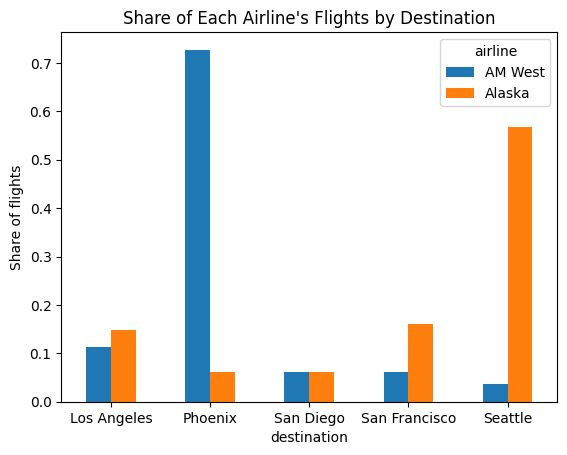

In [7]:
ax = share.plot(kind="bar", rot=0, title="Share of Each Airline's Flights by Destination")
ax.set_ylabel("Share of flights")

## 7. Visualization (delay rate by destination)

This bar chart makes it easy to compare which airline has a higher delay rate for each destination.

Text(0, 0.5, 'Delay rate')

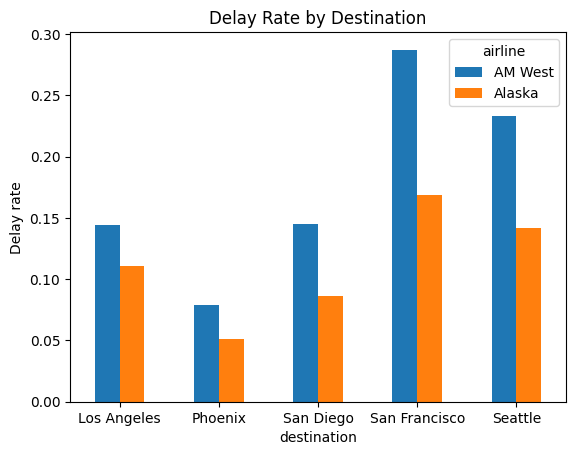

In [8]:
ax = (
    wide.pivot(index="destination", columns="airline", values="delay_rate")
    .plot(kind="bar", rot=0, title="Delay Rate by Destination")
)
ax.set_ylabel("Delay rate")

## 8. Conclusions

**Route-level (by destination):**  
Alaska has the lower delay rate on every destination route in this dataset.

**Overall (weighted):**  
AM West has the lower overall delay rate when aggregating all flights.

**Why this happens:**  
The airlines have very different numbers of flights per destination, so the overall rate is dominated by high-volume routes.

## 9. Brief Reflection

At first, I assumed that the airline with the lower delay rate on every destination (Alaska) would also have the lower overall delay rate. 

However, after calculating the aggregated totals, I saw that the overall result showed the opposite conclusion **(AM West had a lower overall delay rate as compared to Alaska)**. After a few google searches, I realized this was Simpson's paradox, and so changed up my approach.